# 第29章: 不完全データの統計処理

## 学習目標
- MCAR, MAR, MNARを区別できる
- 完全ケース分析の問題点を理解する
- 平均値代入と多重代入を適用できる
- EMアルゴリズムを理解する

## 📋 学習メタ情報

### 推定学習時間
**110〜140分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 29.1 欠測メカニズム

### MCAR (Missing Completely at Random)
欠測は完全にランダム
$$P(R = 0 | Y_{obs}, Y_{mis}) = P(R = 0)$$

### MAR (Missing at Random)
欠測は観測データのみに依存
$$P(R = 0 | Y_{obs}, Y_{mis}) = P(R = 0 | Y_{obs})$$

### MNAR (Missing Not at Random)
欠測は欠測値自体に依存
$$P(R = 0 | Y_{obs}, Y_{mis})$$ が $Y_{mis}$ に依存

In [2]:
# 欠測メカニズムの例
np.random.seed(123)

n = 500

# Complete data
X = np.random.randn(n)
Y = 0.8 * X + np.random.randn(n) * 0.5

# Create different missing mechanisms
missing_rate = 0.3

# MCAR: Random missingness
mask_mcar = np.random.rand(n) < missing_rate
Y_mcar = Y.copy()
Y_mcar[mask_mcar] = np.nan

# MAR: Missingness depends on X
prob_mar = 1 / (1 + np.exp(-2 * X))  # Higher X -> more missing
mask_mar = np.random.rand(n) < prob_mar * 0.5
Y_mar = Y.copy()
Y_mar[mask_mar] = np.nan

# MNAR: Missingness depends on Y itself
prob_mnar = 1 / (1 + np.exp(-2 * Y))  # Higher Y -> more missing
mask_mnar = np.random.rand(n) < prob_mnar * 0.5
Y_mnar = Y.copy()
Y_mnar[mask_mnar] = np.nan

print("欠測メカニズム")
print("="*60)
print(f"\n完全データのYの平均: {np.mean(Y):.3f}")
print(f"\n欠測率:")
print(f"  MCAR: {np.mean(mask_mcar):.1%}")
print(f"  MAR:  {np.mean(mask_mar):.1%}")
print(f"  MNAR: {np.mean(mask_mnar):.1%}")

欠測メカニズム

完全データのYの平均: -0.051

欠測率:
  MCAR: 31.8%
  MAR:  24.8%
  MNAR: 25.4%


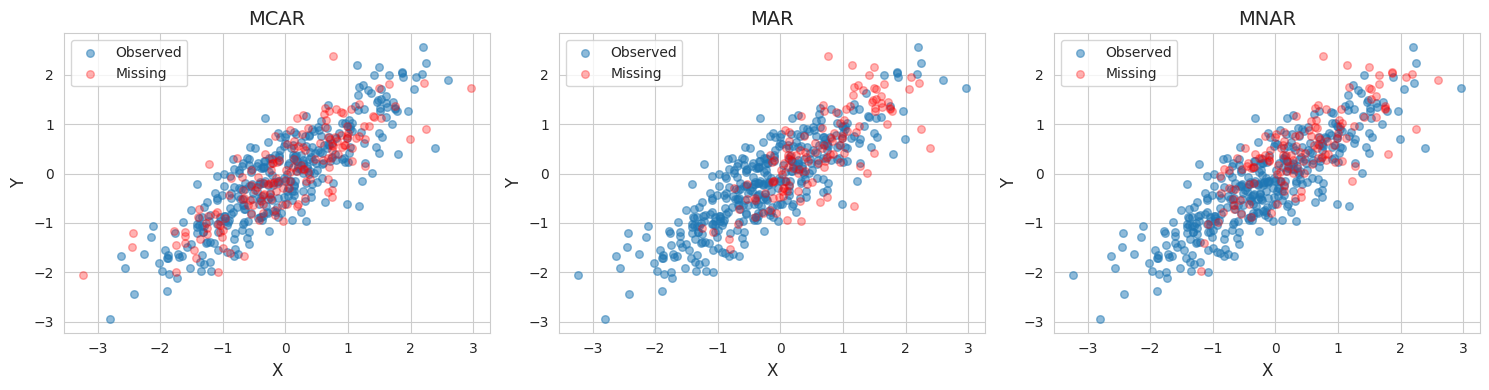

In [3]:
# Visualize missing mechanisms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mask, Y_miss, title in [(axes[0], mask_mcar, Y_mcar, 'MCAR'),
                                  (axes[1], mask_mar, Y_mar, 'MAR'),
                                  (axes[2], mask_mnar, Y_mnar, 'MNAR')]:
    # Plot observed
    ax.scatter(X[~mask], Y[~mask], alpha=0.5, label='Observed', s=30)
    # Plot missing
    ax.scatter(X[mask], Y[mask], alpha=0.3, c='red', label='Missing', s=30)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend()

plt.tight_layout()
plt.show()

## 29.2 完全ケース分析

### 方法
欠測値を含む観測を除外して分析

### 問題点
1. サンプルサイズの減少
2. MCAR以外ではバイアス
3. 情報の損失

In [4]:
# 完全ケース分析
print("完全ケース分析")
print("="*60)

# True values
true_mean = np.mean(Y)
true_corr = np.corrcoef(X, Y)[0, 1]

print(f"\n真の値:")
print(f"  Yの平均: {true_mean:.3f}")
print(f"  X-Y相関: {true_corr:.3f}")

print(f"\n完全ケース分析の結果:")
print(f"{'欠測機構':^10} {'使用n':>8} {'Y平均':>10} {'バイアス':>10} {'相関':>10}")
print("-"*55)

for name, Y_miss, mask in [('MCAR', Y_mcar, mask_mcar),
                            ('MAR', Y_mar, mask_mar),
                            ('MNAR', Y_mnar, mask_mnar)]:
    # Complete cases
    obs_mask = ~np.isnan(Y_miss)
    n_obs = obs_mask.sum()
    mean_cc = np.mean(Y_miss[obs_mask])
    bias = mean_cc - true_mean
    corr_cc = np.corrcoef(X[obs_mask], Y_miss[obs_mask])[0, 1]
    
    print(f"{name:^10} {n_obs:>8} {mean_cc:>10.3f} {bias:>10.3f} {corr_cc:>10.3f}")

完全ケース分析

真の値:
  Yの平均: -0.051
  X-Y相関: 0.851

完全ケース分析の結果:
   欠測機構         使用n        Y平均       バイアス         相関
-------------------------------------------------------
   MCAR         341     -0.076     -0.025      0.855
   MAR          376     -0.217     -0.166      0.849
   MNAR         373     -0.232     -0.181      0.851


## 29.3 平均値代入

### 方法
欠測値を観測値の平均で置換

### 問題点
1. 分散を過小推定
2. 相関を減衰
3. 標準誤差を過小推定

In [5]:
# 平均値代入
print("平均値代入")
print("="*60)

# True variance
true_var = np.var(Y, ddof=1)

print(f"\n真の分散: {true_var:.3f}")

print(f"\n平均値代入の結果:")
print(f"{'欠測機構':^10} {'Y平均':>10} {'Y分散':>10} {'分散比':>10}")
print("-"*45)

for name, Y_miss in [('MCAR', Y_mcar), ('MAR', Y_mar), ('MNAR', Y_mnar)]:
    # Mean imputation
    obs_mask = ~np.isnan(Y_miss)
    mean_obs = np.mean(Y_miss[obs_mask])
    Y_imputed = Y_miss.copy()
    Y_imputed[np.isnan(Y_imputed)] = mean_obs
    
    mean_imp = np.mean(Y_imputed)
    var_imp = np.var(Y_imputed, ddof=1)
    var_ratio = var_imp / true_var
    
    print(f"{name:^10} {mean_imp:>10.3f} {var_imp:>10.3f} {var_ratio:>10.3f}")

print("\n→ 分散が過小推定されている")

平均値代入

真の分散: 0.903

平均値代入の結果:
   欠測機構           Y平均        Y分散        分散比
---------------------------------------------
   MCAR        -0.076      0.651      0.721
   MAR         -0.217      0.635      0.703
   MNAR        -0.232      0.645      0.714

→ 分散が過小推定されている


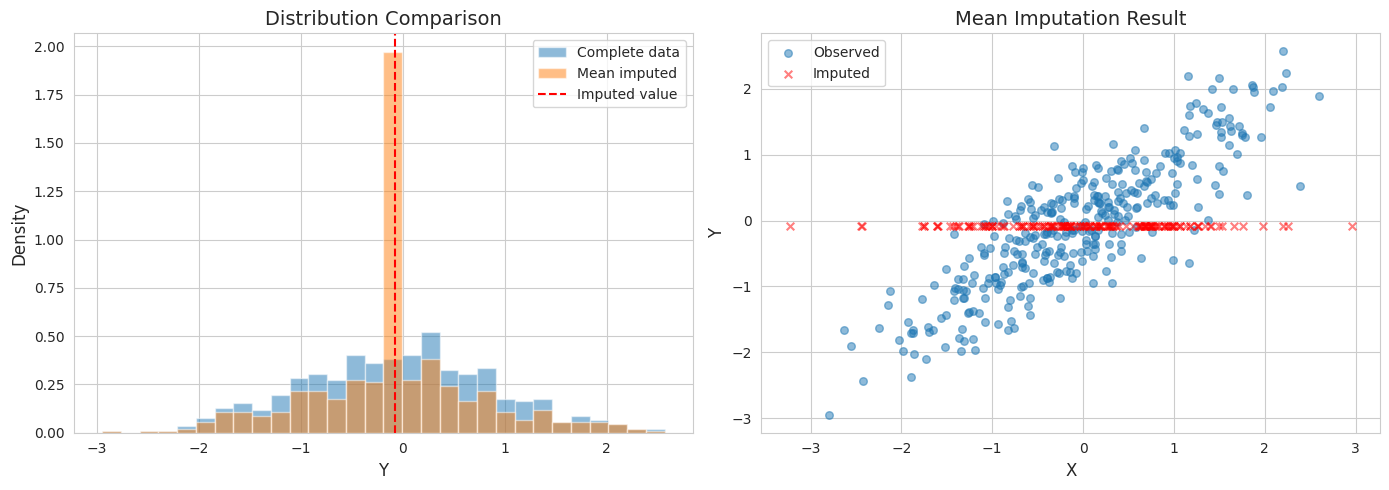

In [6]:
# Visualize mean imputation effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MCAR example
obs_mask = ~np.isnan(Y_mcar)
mean_obs = np.mean(Y_mcar[obs_mask])
Y_imputed = Y_mcar.copy()
Y_imputed[np.isnan(Y_imputed)] = mean_obs

# Histogram comparison
axes[0].hist(Y, bins=30, alpha=0.5, label='Complete data', density=True)
axes[0].hist(Y_imputed, bins=30, alpha=0.5, label='Mean imputed', density=True)
axes[0].axvline(mean_obs, color='red', linestyle='--', label='Imputed value')
axes[0].set_xlabel('Y', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Distribution Comparison', fontsize=14)
axes[0].legend()

# Scatter plot
axes[1].scatter(X[obs_mask], Y_imputed[obs_mask], alpha=0.5, label='Observed', s=30)
axes[1].scatter(X[~obs_mask], Y_imputed[~obs_mask], alpha=0.5, c='red', 
                label='Imputed', s=30, marker='x')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('Y', fontsize=12)
axes[1].set_title('Mean Imputation Result', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 29.4 多重代入法

### 方法
1. 欠測値を複数回（m回）代入してデータセットを作成
2. 各データセットで分析
3. 結果を統合（Rubin's rules）

### 統合ルール
$$\bar{Q} = \frac{1}{m}\sum_{i=1}^{m} \hat{Q}_i$$

$$T = \bar{U} + \left(1 + \frac{1}{m}\right)B$$

- $\bar{U}$: 分散の平均（within imputation）
- $B$: 代入間の分散（between imputation）

In [7]:
# 多重代入法（簡易実装）
def multiple_imputation_regression(X, Y_miss, m=5):
    """Simple multiple imputation using regression."""
    obs_mask = ~np.isnan(Y_miss)
    n = len(Y_miss)
    
    # Fit regression on complete cases
    X_obs = X[obs_mask]
    Y_obs = Y_miss[obs_mask]
    
    # Simple linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(X_obs, Y_obs)
    residual_var = np.var(Y_obs - (intercept + slope * X_obs), ddof=2)
    
    # Generate m imputed datasets
    imputed_datasets = []
    for i in range(m):
        Y_imp = Y_miss.copy()
        # Predict with noise
        predicted = intercept + slope * X[~obs_mask]
        noise = np.random.randn(np.sum(~obs_mask)) * np.sqrt(residual_var)
        Y_imp[~obs_mask] = predicted + noise
        imputed_datasets.append(Y_imp)
    
    return imputed_datasets

# Apply multiple imputation
m = 10
imputed_datasets = multiple_imputation_regression(X, Y_mcar, m=m)

print("多重代入法")
print("="*60)

# Analyze each dataset
means = [np.mean(Y_imp) for Y_imp in imputed_datasets]
variances = [np.var(Y_imp, ddof=1) / len(Y_imp) for Y_imp in imputed_datasets]  # SE^2

# Combine results (Rubin's rules)
Q_bar = np.mean(means)
U_bar = np.mean(variances)  # Within imputation variance
B = np.var(means, ddof=1)   # Between imputation variance
T = U_bar + (1 + 1/m) * B   # Total variance

print(f"\n代入回数: m = {m}")
print(f"\n各代入の平均: {[f'{m:.3f}' for m in means]}")
print(f"\n統合結果:")
print(f"  推定値: {Q_bar:.3f}")
print(f"  標準誤差: {np.sqrt(T):.3f}")
print(f"  真の平均: {true_mean:.3f}")

多重代入法

代入回数: m = 10

各代入の平均: ['-0.050', '-0.054', '-0.047', '-0.062', '-0.060', '-0.036', '-0.043', '-0.051', '-0.063', '-0.040']

統合結果:
  推定値: -0.051
  標準誤差: 0.044
  真の平均: -0.051


## 29.5 EMアルゴリズム

### 概要
欠測データの最尤推定に使用

### 手順
1. **E-step**: 欠測値の条件付き期待値を計算
2. **M-step**: 期待値を用いてパラメータを更新

### 多変量正規分布の場合
$$E[Y_{mis} | Y_{obs}, \theta^{(t)}]$$

In [8]:
# EMアルゴリズム（二変量正規分布）
def em_algorithm_bivariate(X, Y_miss, max_iter=100, tol=1e-6):
    """EM algorithm for bivariate normal with missing Y values."""
    n = len(X)
    obs_mask = ~np.isnan(Y_miss)
    
    # Initial estimates from complete cases
    X_obs = X[obs_mask]
    Y_obs = Y_miss[obs_mask]
    
    mu_x = np.mean(X)
    mu_y = np.mean(Y_obs)
    var_x = np.var(X, ddof=1)
    var_y = np.var(Y_obs, ddof=1)
    cov_xy = np.cov(X_obs, Y_obs)[0, 1]
    
    history = []
    
    for iteration in range(max_iter):
        # E-step: Compute expected sufficient statistics
        # For missing Y: E[Y|X] = mu_y + (cov_xy/var_x) * (X - mu_x)
        beta = cov_xy / var_x
        Y_imputed = Y_miss.copy()
        Y_imputed[~obs_mask] = mu_y + beta * (X[~obs_mask] - mu_x)
        
        # Conditional variance: Var(Y|X)
        cond_var = var_y - cov_xy**2 / var_x
        
        # M-step: Update parameters
        mu_y_new = np.mean(Y_imputed)
        
        # Variance including uncertainty
        var_y_new = (np.sum((Y_imputed - mu_y_new)**2) + 
                     np.sum(~obs_mask) * cond_var) / n
        
        cov_xy_new = np.sum((X - mu_x) * (Y_imputed - mu_y_new)) / n
        
        history.append({'mu_y': mu_y_new, 'var_y': var_y_new, 'cov_xy': cov_xy_new})
        
        # Check convergence
        if abs(mu_y_new - mu_y) < tol and abs(var_y_new - var_y) < tol:
            break
        
        mu_y = mu_y_new
        var_y = var_y_new
        cov_xy = cov_xy_new
    
    return mu_y, var_y, cov_xy, history

# Apply EM algorithm
mu_y_em, var_y_em, cov_xy_em, history = em_algorithm_bivariate(X, Y_mcar)

print("EMアルゴリズム")
print("="*60)
print(f"\n収束までの反復回数: {len(history)}")

print(f"\n推定結果:")
print(f"  μ_Y (EM): {mu_y_em:.3f}, 真の値: {true_mean:.3f}")
print(f"  σ²_Y (EM): {var_y_em:.3f}, 真の値: {true_var:.3f}")
print(f"  相関 (EM): {cov_xy_em / np.sqrt(var_y_em * np.var(X)):.3f}, 真の値: {true_corr:.3f}")

EMアルゴリズム

収束までの反復回数: 10

推定結果:
  μ_Y (EM): -0.054, 真の値: -0.051
  σ²_Y (EM): 0.935, 真の値: 0.903
  相関 (EM): 0.852, 真の値: 0.851


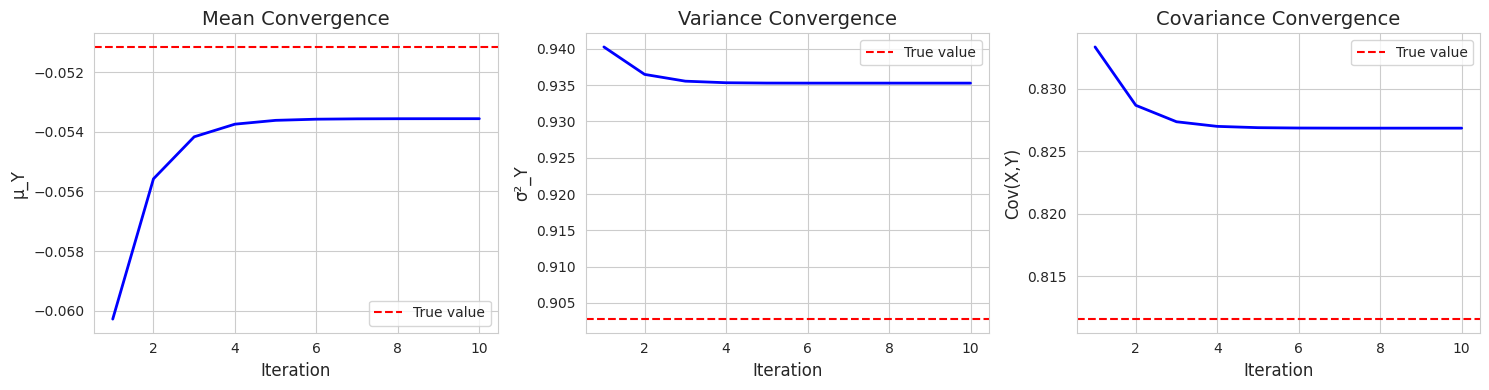

In [9]:
# Visualize EM convergence
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

iterations = range(1, len(history) + 1)

# Mean
axes[0].plot(iterations, [h['mu_y'] for h in history], 'b-', linewidth=2)
axes[0].axhline(true_mean, color='red', linestyle='--', label='True value')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('μ_Y', fontsize=12)
axes[0].set_title('Mean Convergence', fontsize=14)
axes[0].legend()

# Variance
axes[1].plot(iterations, [h['var_y'] for h in history], 'b-', linewidth=2)
axes[1].axhline(true_var, color='red', linestyle='--', label='True value')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('σ²_Y', fontsize=12)
axes[1].set_title('Variance Convergence', fontsize=14)
axes[1].legend()

# Covariance
true_cov = np.cov(X, Y)[0, 1]
axes[2].plot(iterations, [h['cov_xy'] for h in history], 'b-', linewidth=2)
axes[2].axhline(true_cov, color='red', linestyle='--', label='True value')
axes[2].set_xlabel('Iteration', fontsize=12)
axes[2].set_ylabel('Cov(X,Y)', fontsize=12)
axes[2].set_title('Covariance Convergence', fontsize=14)
axes[2].legend()

plt.tight_layout()
plt.show()

## 29.6 練習問題

### 問題1
MCARとMARの違いを具体例で説明せよ。

### 問題2
平均値代入の問題点を3つ挙げよ。

### 問題3
多重代入法でm=1とした場合の問題点を説明せよ。

In [10]:
# 問題1の解答
print("問題1: MCARとMARの違い")
print("="*60)

print("""
【MCAR (Missing Completely at Random)】
欠測は完全にランダム

例: アンケート調査で、コインを投げて表なら回答をスキップ
→ 欠測は回答内容にも質問者の属性にも無関係

【MAR (Missing at Random)】
欠測は観測データに依存

例: 収入調査で、若年層ほど回答しない傾向がある
→ 欠測は年齢（観測）に依存するが、
   収入（欠測値）自体には依存しない

【違いの重要性】
・MCAR: 完全ケース分析でも不偏
・MAR: 観測変数を条件付ければ適切に処理可能
・MNAR: 特殊なモデリングが必要
""")

問題1: MCARとMARの違い

【MCAR (Missing Completely at Random)】
欠測は完全にランダム

例: アンケート調査で、コインを投げて表なら回答をスキップ
→ 欠測は回答内容にも質問者の属性にも無関係

【MAR (Missing at Random)】
欠測は観測データに依存

例: 収入調査で、若年層ほど回答しない傾向がある
→ 欠測は年齢（観測）に依存するが、
   収入（欠測値）自体には依存しない

【違いの重要性】
・MCAR: 完全ケース分析でも不偏
・MAR: 観測変数を条件付ければ適切に処理可能
・MNAR: 特殊なモデリングが必要



In [11]:
# 問題2の解答
print("問題2: 平均値代入の問題点")
print("="*60)

print("""
【問題点】

1. 分散の過小推定
   - すべての欠測値が同じ値（平均）に置換される
   - データの変動が人工的に減少

2. 相関の減衰
   - 代入された値は他の変数との関係を反映しない
   - 変数間の相関係数が0に近づく

3. 標準誤差の過小推定
   - 代入の不確実性を考慮しない
   - 見かけ上のサンプルサイズが増加
   - 信頼区間が狭くなりすぎる

【結果】
・検定で誤った棄却が増加
・効果量の過小推定
・予測精度の低下
""")

問題2: 平均値代入の問題点

【問題点】

1. 分散の過小推定
   - すべての欠測値が同じ値（平均）に置換される
   - データの変動が人工的に減少

2. 相関の減衰
   - 代入された値は他の変数との関係を反映しない
   - 変数間の相関係数が0に近づく

3. 標準誤差の過小推定
   - 代入の不確実性を考慮しない
   - 見かけ上のサンプルサイズが増加
   - 信頼区間が狭くなりすぎる

【結果】
・検定で誤った棄却が増加
・効果量の過小推定
・予測精度の低下



In [12]:
# 問題3の解答
print("問題3: m=1の問題点")
print("="*60)

print("""
【m=1（単一代入）の問題点】

1. 代入の不確実性を無視
   - 欠測値の推定には誤差がある
   - 1回の代入ではこの不確実性を捕捉できない

2. 標準誤差の過小推定
   - between imputation variance B = 0
   - 総分散 T = U（within varianceのみ）
   - 真の不確実性より小さい

3. 信頼区間が狭すぎる
   - 過度に楽観的な推定
   - カバー率が名目より低下

【推奨されるm】
・通常 m = 5〜20
・欠測率が高い場合はmを増やす
・m ≥ 20 あれば十分な効率
""")

問題3: m=1の問題点

【m=1（単一代入）の問題点】

1. 代入の不確実性を無視
   - 欠測値の推定には誤差がある
   - 1回の代入ではこの不確実性を捕捉できない

2. 標準誤差の過小推定
   - between imputation variance B = 0
   - 総分散 T = U（within varianceのみ）
   - 真の不確実性より小さい

3. 信頼区間が狭すぎる
   - 過度に楽観的な推定
   - カバー率が名目より低下

【推奨されるm】
・通常 m = 5〜20
・欠測率が高い場合はmを増やす
・m ≥ 20 あれば十分な効率



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---